In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report,confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, roc_curve


In [2]:
df = pd.read_csv('/content/spam.csv', encoding='latin-1')
display(df.head())

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df_nueva_data = df[['v1', 'v2']]

df_nueva_data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df_nueva_data = df_nueva_data.rename(
    columns={
        "v1":"categoria",
        "v2":"categoria_2"
    }
)

In [5]:
df_nueva_data.tail(10)

,categoria,categoria_2
5562,ham,Ok lor... Sony ericsson salesman... I ask shuh...
5563,ham,Ard 6 like dat lor.
5564,ham,Why don't you wait 'til at least wednesday to ...
5565,ham,Huh y lei...
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [6]:
df_nueva_data.head(10)

,categoria,categoria_2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [7]:
X = df_nueva_data['categoria_2']
y = df_nueva_data['categoria']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 19)

In [9]:
vectorizador = CountVectorizer()
X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)

#Modelo de Gaussian NB

In [10]:
gaussian = GaussianNB()
gaussian.fit(X_train_vec.toarray(), y_train)

GaussianNB()

In [11]:
y_pred = gaussian.predict(X_test_vec.toarray())
print(y_pred)

['ham' 'spam' 'spam' ... 'spam' 'spam' 'ham']


In [12]:
accurracy = accuracy_score(y_test, y_pred)
print("El accurracy de Gaussian NB:", accurracy)

El accurracy de Gaussian NB: 0.9061004784688995


El modelo Gaussian NB clasificó correctamente el 90.61% de todos los mensajes del conjunto de prueba. Aunque parece un valor alto, este resultado puede estar influenciado por el desbalance entre clases (1425 spam vs 247 ham), por lo que es necesario analizar métricas adicionales para evaluar el rendimiento real del modelo.

In [13]:
f1 = f1_score(y_test, y_pred, pos_label='spam')
print("F1 score de Gaussian NB:", f1)

F1 score de Gaussian NB: 0.740495867768595


El F1-Score combina precisión y recall en una sola métrica mediante su media armónica. Un valor de 0.7405 indica un equilibrio moderado entre ambas métricas para la clase spam. Este valor relativamente bajo se explica por la baja precisión del modelo (0.6257), lo que significa que sacrifica exactitud a cambio de detectar más mensajes spam.

In [14]:
report = classification_report(y_test, y_pred, target_names=['spam','ham'])
print(report)

              precision    recall  f1-score   support

        spam       0.98      0.91      0.94      1425
         ham       0.63      0.91      0.74       247

    accuracy                           0.91      1672
   macro avg       0.80      0.91      0.84      1672
weighted avg       0.93      0.91      0.91      1672



El reporte muestra un comportamiento asimétrico entre clases. Para spam, el modelo alcanza una precisión de 0.98 y un recall de 0.91, lo que indica que detecta bien el spam real pero con muy pocos falsos positivos en esa clase. Sin embargo, para ham la precisión cae a 0.63 y el recall es 0.91, revelando que el modelo confunde frecuentemente mensajes legítimos con spam. El macro avg de F1 en 0.84 refleja esta diferencia de rendimiento entre clases.

In [15]:
precision = precision_score(y_test, y_pred, pos_label='spam')
print("Precision de Gaussian NB:", precision)

Precision de Gaussian NB: 0.6256983240223464


De todos los mensajes que el modelo predijo como spam, solo el 62.57% realmente lo eran. Esto significa que el modelo genera una cantidad considerable de falsos positivos: mensajes ham que están siendo marcados incorrectamente como spam, lo cual es problemático para el usuario porque perdería correos legítimos.

In [16]:
recall = recall_score(y_test, y_pred, pos_label='spam')
print("Recall de Gaussian NB:", recall)

Recall de Gaussian NB: 0.9068825910931174


El modelo detectó el 90.69% de todos los mensajes spam reales del conjunto de prueba. Esto indica una sensibilidad alta: el modelo es capaz de identificar la gran mayoría del spam existente, aunque a costa de etiquetar erróneamente algunos mensajes ham.

In [17]:
matrix_confusion = confusion_matrix(y_test, y_pred)
print("Matriz de confusión del Gaussian NB:")
print(matrix_confusion)

Matriz de confusión del Gaussian NB:
[[1291  134]
 [  23  224]]


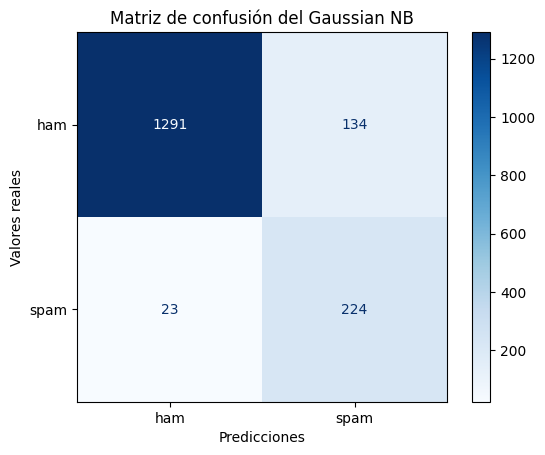

In [18]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Matriz de confusión del Gaussian NB")
plt.xlabel("Predicciones")
plt.ylabel("Valores reales")
plt.show()

El modelo clasificó correctamente 1291 mensajes ham (verdaderos negativos) y 224 mensajes spam (verdaderos positivos). Cometió 134 falsos positivos, es decir, mensajes ham clasificados como spam, lo cual representa el principal problema del modelo. Solo cometió 23 falsos negativos, mensajes spam que pasaron como ham. Este desbalance confirma que el Gaussian NB tiende a sobre-clasificar como spam.

In [19]:
y_proba = gaussian.predict_proba(X_test_vec.toarray())[:,1]
print(y_proba)

[0. 1. 1. ... 1. 1. 0.]


In [20]:
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC AUC de Gaussian NB:", roc_auc)

ROC AUC de Gaussian NB: 0.9064237516869096


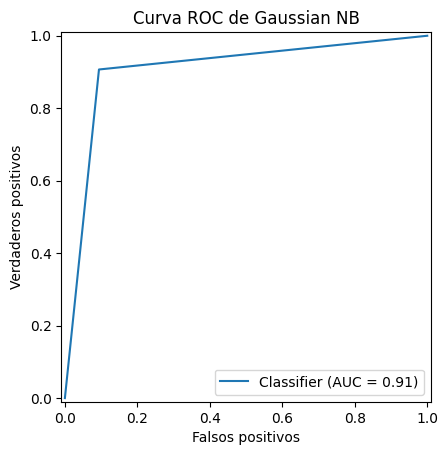

In [21]:
RocCurveDisplay.from_predictions(y_test, y_proba, pos_label='spam')
plt.title("Curva ROC de Gaussian NB")
plt.xlabel("Falsos positivos")
plt.ylabel("Verdaderos positivos")
plt.show()

El área bajo la curva ROC de 0.9064 indica que el modelo tiene buena capacidad general para distinguir entre spam y ham a diferentes umbrales de decisión. Sin embargo, la curva ROC no refleja el problema de los falsos positivos en ham, por lo que este valor no debe interpretarse de forma aislada.

#Modelo Multinomial NB

In [22]:
#implementar multinomial nb (con f1, report, ect), metricas, graficas, interpretación de resultados
modeloM = MultinomialNB()
modeloM.fit(X_train_vec, y_train)

MultinomialNB()

In [23]:
y_predM = modeloM.predict(X_test_vec)
print(y_predM)

['ham' 'spam' 'ham' ... 'spam' 'spam' 'ham']


In [24]:
accuracyM = accuracy_score(y_test, y_predM)
print("El accurracy de Multinomial NB:", accuracyM)

El accurracy de Multinomial NB: 0.9856459330143541


El Multinomial NB clasificó correctamente el 98.56% de todos los mensajes, una mejora de casi 8 puntos porcentuales respecto al modelo Gaussiano. Este resultado es más confiable porque el modelo también mantiene un alto rendimiento en ambas clases por separado, como se confirma con las demás métricas.

In [25]:
f1M = f1_score(y_test, y_predM, pos_label='spam')
print("F1 score del Multinomial NB:", f1M)

F1 score del Multinomial NB: 0.9504132231404959


Un F1-Score de 0.9504 refleja un equilibrio muy sólido entre precisión (0.9705) y recall (0.9311) para la clase spam. A diferencia del Gaussian NB, este modelo no sacrifica una métrica a favor de la otra, lo que lo convierte en un clasificador más confiable y equilibrado para esta tarea.

In [26]:
reportM = classification_report(y_test, y_predM, target_names=['spam', 'ham'])
print(reportM)

              precision    recall  f1-score   support

        spam       0.99      1.00      0.99      1425
         ham       0.97      0.93      0.95       247

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



El reporte del Multinomial NB muestra un rendimiento consistente en ambas clases. Para spam: precisión 0.99 y recall 1.00, es decir, detecta prácticamente todo el spam sin generar casi falsos positivos. Para ham: precisión 0.97 y recall 0.93, rendimiento también muy alto. El macro avg de F1 en 0.97 confirma que el modelo es sólido tanto para mensajes spam como para mensajes legítimos, sin favorecer una clase sobre la otra.

In [27]:
recallM = recall_score(y_test, y_predM, pos_label='spam')
print("Recall del Multinomial NB:", recallM)

Recall del Multinomial NB: 0.9311740890688259


El modelo detectó el 93.11% de todos los mensajes spam reales. Aunque es ligeramente menor que el recall del Gaussian NB (0.9069 vs 0.9311 a favor del Multinomial), la diferencia clave está en que este modelo logra ese recall sin sacrificar la precisión, lo que lo hace superior en conjunto.

In [28]:
precisionM = precision_score(y_test, y_predM, pos_label='spam')
print("Precision del Multinomial NB:", precisionM)

Precision del Multinomial NB: 0.9704641350210971


El 97.05% de los mensajes clasificados como spam realmente lo eran. La tasa de falsos positivos es mínima, lo que significa que prácticamente ningún mensaje legítimo es bloqueado incorrectamente. Esto representa una mejora de más de 34 puntos porcentuales respecto al Gaussian NB (0.6257).

In [29]:
matrix_confusionM = confusion_matrix(y_test, y_predM)
print("Matriz de confusión del Multinomial NB:")
print(matrix_confusionM)

Matriz de confusión del Multinomial NB:
[[1418    7]
 [  17  230]]


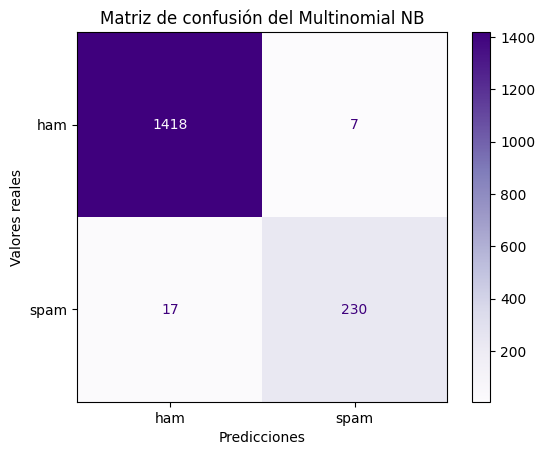

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predM, cmap='Purples')
plt.title("Matriz de confusión del Multinomial NB")
plt.xlabel("Predicciones")
plt.ylabel("Valores reales")
plt.show()

El modelo clasificó correctamente 1418 mensajes ham y 230 mensajes spam. Solo cometió 7 falsos positivos (ham clasificado como spam) y 17 falsos negativos (spam clasificado como ham). Comparado con los 134 falsos positivos del Gaussian NB, esta reducción es drástica y representa el principal punto fuerte del Multinomial NB: protege los mensajes legítimos del usuario.

In [31]:
y_probaM = modeloM.predict_proba(X_test_vec)[:,1]
print(y_probaM)

[4.70748147e-12 9.99932537e-01 1.72196592e-05 ... 1.00000000e+00
 9.99995748e-01 2.30994979e-10]


In [32]:
roc_aucM = roc_auc_score(y_test, y_probaM)
print("ROC AUC del Multinomial NB:", roc_aucM)

ROC AUC del Multinomial NB: 0.9891895731230911


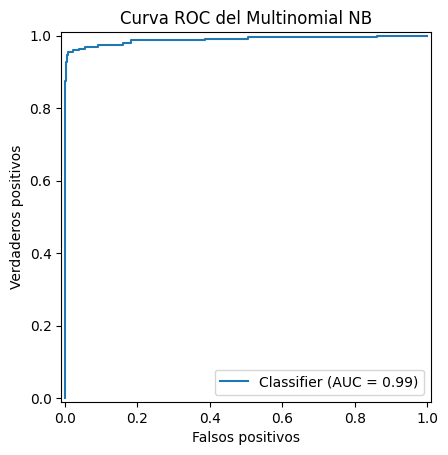

In [33]:
RocCurveDisplay.from_predictions(y_test, y_probaM, pos_label='spam')
plt.title("Curva ROC del Multinomial NB")
plt.xlabel("Falsos positivos")
plt.ylabel("Verdaderos positivos")
plt.show()

Un AUC de 0.9892 es prácticamente perfecto, confirmando que el Multinomial NB separa las clases spam y ham con altísima eficacia a cualquier umbral de decisión. Supera en casi 9 puntos al Gaussian NB (0.9064), lo que se ve claramente en la curva ROC comparativa donde la curva naranja abraza la esquina superior izquierda mucho más que la azul.

#Tabla y grafica comparativa de los dos modelos

In [34]:
tabla = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (spam)', 'Recall (spam)', 'F1-Score (spam)', 'ROC AUC'],
    'Gaussian NB': [
        round(accuracy_score(y_test, y_pred), 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(roc_auc, 4)
    ],
    'Multinomial NB': [
        round(accuracy_score(y_test, y_predM), 4),
        round(precisionM, 4),
        round(recallM, 4),
        round(f1M, 4),
        round(roc_aucM, 4)
    ]
})

tabla = tabla.set_index('Métrica')
print(tabla.to_string())

                  Gaussian NB  Multinomial NB
Métrica                                      
Accuracy               0.9061          0.9856
Precision (spam)       0.6257          0.9705
Recall (spam)          0.9069          0.9312
F1-Score (spam)        0.7405          0.9504
ROC AUC                0.9064          0.9892


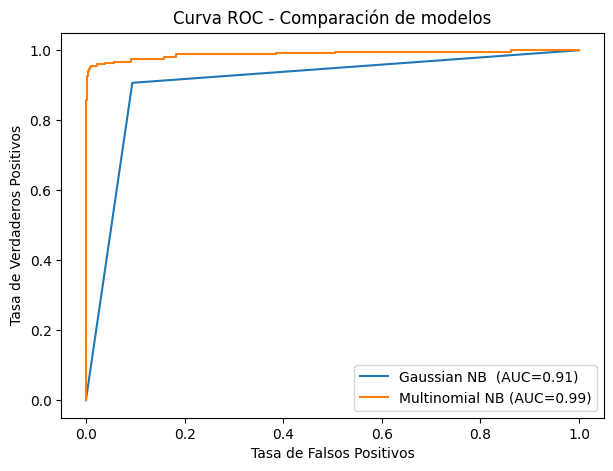

In [35]:
fpr_g, tpr_g, _ = roc_curve((y_test == 'spam').astype(int), y_proba)
fpr_m, tpr_m, _ = roc_curve((y_test == 'spam').astype(int), y_probaM)
plt.figure(figsize=(7,5))
plt.plot(fpr_g, tpr_g, label=f'Gaussian NB  (AUC={roc_auc:.2f})')
plt.plot(fpr_m, tpr_m, label=f'Multinomial NB (AUC={roc_aucM:.2f})')
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC - Comparación de modelos")
plt.legend()
plt.show()

La tabla y la curva ROC comparativa confirman que el Multinomial NB es superior en todas las métricas evaluadas. La diferencia más crítica se observa en Precision (0.6257 vs 0.9705) y F1-Score (0.7405 vs 0.9504), lo que evidencia que el modelo Gaussiano, al asumir distribución normal en los datos, no es adecuado para texto vectorizado con CountVectorizer. El Multinomial NB, diseñado para frecuencias de ocurrencia de palabras, es la elección correcta para clasificación de mensajes spam.